# Imports y funciones

In [1]:
from utils import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Estilo sobrio con LaTeX
plt.style.use("default")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

# Paleta de colores sobrios
grad_color = "#222222"  # casi negro para ||g_k||
color_list = [
    "#006400",  # verde oscuro
    "#1f4e79",  # azul oscuro
    "#8b0000",  # rojo oscuro
    "#a05000",  # naranja oscuro
]
marker_list = ["o", "s", "^", "D"]  # 4 tipos de marcadores

import pickle

def load_dict_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)



# Plots

Media

ViT-B_16 on CIFAR-100: 27 runs
0.9-0.9: 98.916 || 61.22
0.9-0.99: 98.95 || 61.14
0.9-0.999: 99.002 || 61.12
0.99-0.9: 67.654 || 53.57
0.99-0.99: 98.694 || 60.75
0.99-0.999: 98.784 || 60.49
0.999-0.9: 7.648 || 8.34
0.999-0.99: 35.67 || 35.29
0.999-0.999: 64.112 || 50.42


c:\Users\aferher1\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\aferher1\AppData\Local\Temp\ipykernel_14112\412189320.py:43: RuntimeWarning: invalid value encountered in subtract
  return float(np.mean(np.abs(datos[1:] - datos[:-1])))


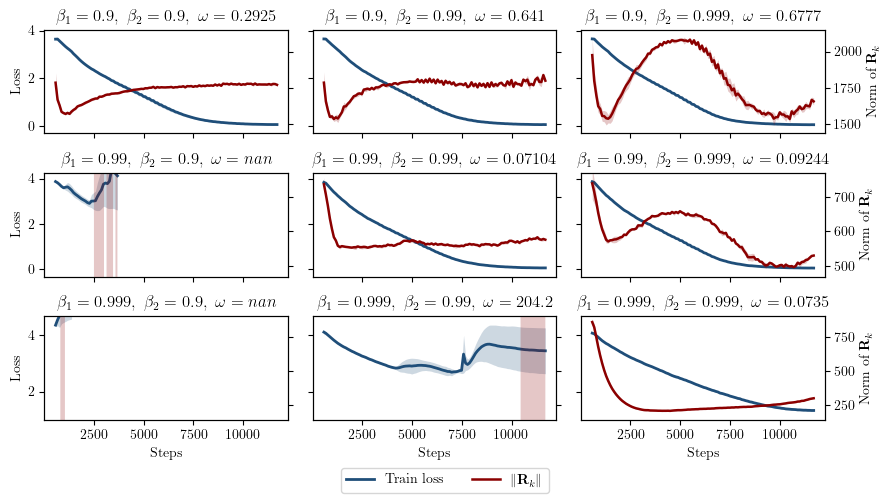

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("plots", exist_ok=True)

cases = [
    ("NanoGPT",         "SlimPajama"),   # primero
    ("EfficientNet-B0", "TinyImageNet"),
    ("T5",              "SQuAD"),
    ("ResNet18",        "CIFAR-100"),
    ("NanoGPT",         "WikiText"),
    ("ViT-B_16",        "CIFAR-100"),
]
cases = [    ("ViT-B_16",        "CIFAR-100"),
]

for model, dataset in cases:
    data_dict = load_dict_pickle(f"results/{model}_{dataset}.pkl")

    epochs = data_dict["epochs"]
    data = data_dict["runs"]

    print(f"{model} on {dataset}: {len(data)} runs")

    def ema(datos, ventana=200):
        datos = np.asarray(datos, dtype=float)
        n = len(datos)
        if n == 0:
            return np.array([], dtype=float)
        out = np.empty(n, dtype=float)
        alpha = 2.0 / (ventana + 1.0)
        out[0] = datos[0]
        for i in range(1, n):
            out[i] = alpha * datos[i] + (1.0 - alpha) * out[i-1]
        return out

    def osc1(datos):
        datos = np.asarray(datos, dtype=float)
        n = datos.size
        if n < 2:
            return 0.0
        return float(np.mean(np.abs(datos[1:] - datos[:-1])))

    # --- Estilo ---
    grad_color = "#222222"
    color_loss = "#1f4e79"
    color_R    = "#8b0000"

    # Hiperparámetros
    mult = 100
    ema_window = 200
    fill_alpha = 0.22
    lw_loss = 2.0
    lw_R = 1.8

    # "3 epochs" de warmup, pero si epochs es pequeño no recortamos
    skip_epochs = 3

    beta1_list = [0.9, 0.99, 0.999]
    beta2_list = [0.9, 0.99, 0.999]

    fig, axes = plt.subplots(
        nrows=3, ncols=3, figsize=(9, 5),
        sharex=True, sharey=False
    )

    global_handle_loss = None
    global_handle_R = None
    cache = [[None]*3 for _ in range(3)]

    # ---------- PRECOMPUTE ----------
    for ax_i, beta1 in enumerate(beta1_list):
        for ax_j, beta2 in enumerate(beta2_list):
            loss_runs = []
            r_runs = []
            train_metric = []
            val_metric = []

            available_seeds = sorted({k[2] for k in data.keys() if k[0] == beta1 and k[1] == beta2})
            for seed in available_seeds:
                run_data = data[(beta1, beta2, seed)]
                loss_runs.append(run_data["train_step_loss"])
                r_runs.append(run_data["updates_norm"])
                train_metric.append(run_data["train_metric"])
                val_metric.append(run_data["val_metric"])

            print(f"{beta1}-{beta2}: {np.max(train_metric)} || {np.max(val_metric)}")

            loss_runs = np.asarray(loss_runs, dtype=float)
            r_runs    = np.asarray(r_runs, dtype=float)

            # start robusto: si epochs <= skip_epochs => start=0
            T = loss_runs.shape[1]
            if epochs <= skip_epochs:
                start = 0
            else:
                start = int(skip_epochs * T / epochs)
            start = min(start, T - 1)

            loss_runs = loss_runs[:, start:]
            r_runs    = r_runs[:, start:]

            x_full = np.arange(loss_runs.shape[1]) + start

            loss_runs_e = np.array([ema(x, ventana=ema_window) for x in loss_runs])
            r_runs_e    = np.array([ema(x, ventana=ema_window) for x in r_runs])

            loss_mean_e = np.mean(loss_runs_e, axis=0)
            loss_std_e  = np.std(loss_runs_e, axis=0)
            loss_lo_e   = loss_mean_e - loss_std_e
            loss_hi_e   = loss_mean_e + loss_std_e

            r_mean_e = np.mean(r_runs_e, axis=0)
            r_std_e  = np.std(r_runs_e, axis=0)
            r_lo_e   = r_mean_e - r_std_e
            r_hi_e   = r_mean_e + r_std_e

            omega_runs = np.array([osc1(x) for x in r_runs_e])

            omega = float(np.mean(omega_runs))

            sl = slice(None, None, mult)
            x = x_full[sl]

            cache[ax_i][ax_j] = dict(
                x=x,
                loss_mean=loss_mean_e[sl], loss_lo=loss_lo_e[sl], loss_hi=loss_hi_e[sl],
                r_mean=r_mean_e[sl],       r_lo=r_lo_e[sl],       r_hi=r_hi_e[sl],
                omega=omega
            )

    # ---------- PLOT ----------
    for ax_i, beta1 in enumerate(beta1_list):
        loss_min = +np.inf
        loss_max = -np.inf
        r_min = +np.inf
        r_max = -np.inf

        for ax_j in range(3):
            d = cache[ax_i][ax_j]

            # LOSS: toda la fila
            loss_min = max(0, min(loss_min, np.percentile(d["loss_lo"], 1)))
            loss_max = max(loss_max, np.percentile(d["loss_hi"], 99))

            # R: diagonal y derecha
            if ax_j < ax_i:
                continue
            r_min = max(0, min(r_min, np.percentile(d["r_lo"], 1)))
            r_max = max(r_max, np.percentile(d["r_hi"], 99))

        loss_pad = 0.1 * (loss_max - loss_min + 1e-12)
        r_pad    = 0.1 * (r_max - r_min + 1e-12)

        for ax_j, beta2 in enumerate(beta2_list):
            ax = axes[ax_i, ax_j]
            d = cache[ax_i][ax_j]

            # Loss band + line
            ax.fill_between(d["x"], d["loss_lo"], d["loss_hi"], linewidth=0.0, color=color_loss, alpha=fill_alpha)
            line_loss = ax.plot(d["x"], d["loss_mean"], linestyle="-", linewidth=lw_loss, color=color_loss, label=r"Train loss")[0]

            # X label solo en la fila de abajo
            if ax_i == len(beta1_list) - 1:
                ax.set_xlabel(r"Steps")
                ax.tick_params(axis="x", which="both", labelbottom=True)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis="x", which="both", labelbottom=False)

            # Y1 label + ticks solo en la columna izquierda
            if ax_j == 0:
                ax.set_ylabel(r"Loss")
                ax.tick_params(axis="y", which="both", labelleft=True)
            else:
                ax.set_ylabel("")
                ax.tick_params(axis="y", which="both", labelleft=False)

            ax.set_ylim(loss_min - loss_pad, loss_max + loss_pad)

            # Twin axis para R
            ax2 = ax.twinx()

            ax2.fill_between(d["x"], d["r_lo"], d["r_hi"], linewidth=0.0, color=color_R, alpha=fill_alpha)
            line_R = ax2.plot(d["x"], d["r_mean"], linestyle="-", linewidth=lw_R, color=color_R, label=r"$\|\mathbf{R}_k\|$")[0]

            # Y2 label + ticks solo en la columna derecha
            if ax_j == len(beta2_list) - 1:
                ax2.set_ylabel(r"Norm of $\mathbf{R}_k$")
                ax2.tick_params(axis="y", which="both", labelright=True)
            else:
                ax2.set_ylabel("")
                ax2.tick_params(axis="y", which="both", labelright=False)

            ax2.set_ylim(r_min - r_pad, r_max + r_pad)

            # Título
            ax.set_title(rf"$\beta_1={beta1},\ \beta_2={beta2},\ \omega={d['omega']:.4g}$")

            if global_handle_loss is None:
                global_handle_loss = line_loss
            if global_handle_R is None:
                global_handle_R = line_R

    # Leyenda global abajo
    handles = [global_handle_loss, global_handle_R]
    labels  = [h.get_label() for h in handles]
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=True, fontsize=10, bbox_to_anchor=(0.5, -0.01))

    fig.tight_layout(rect=(0, 0.04, 1, 1))

    plt.savefig(f"plots/experiment_{model}_{dataset}.pdf", bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)


CÓDIGO PARA SACAR OSCILACIONES Y CONTRASTE DE HIPÓTESIS

In [3]:
import numpy as np

# --- Necesitas tener definida esta función en tu entorno, tal como la usas ya ---
# def load_dict_pickle(path): ...

# ----------------------------
# Helpers numéricos (independientes)
# ----------------------------
def ema(x, window=200):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n == 0:
        return np.array([], dtype=float)
    out = np.empty(n, dtype=float)
    alpha = 2.0 / (window + 1.0)
    out[0] = x[0]
    for i in range(1, n):
        out[i] = alpha * x[i] + (1.0 - alpha) * out[i - 1]
    return out

def osc1(x):
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return 0.0
    return float(np.mean(np.abs(x[1:] - x[:-1])))

def _safe_start_index(T, epochs, skip_epochs):
    if T <= 0:
        return 0
    if epochs is None or epochs <= 0:
        return 0
    if epochs <= skip_epochs:
        return 0
    start = int(skip_epochs * T / epochs)
    return int(np.clip(start, 0, T - 1))

def _format_matrix(M, beta1_vals, beta2_vals, fmt="{:.4g}"):
    """
    Pretty print de una matriz beta1 x beta2 con cabeceras.
    """
    b2_hdr = "beta2 -> " + "  ".join([f"{b2:g}" for b2 in beta2_vals])
    lines = [b2_hdr]
    for i, b1 in enumerate(beta1_vals):
        row = []
        for j in range(len(beta2_vals)):
            v = M[i, j]
            row.append("nan" if not np.isfinite(v) else fmt.format(v))
        lines.append(f"beta1={b1:g} | " + "  ".join(f"{x:>8}" for x in row))
    return "\n".join(lines)

# ----------------------------
# Extracción principal
# ----------------------------
def extract_osc1_grid(
    pkl_path,
    *,
    r_key="updates_norm",
    ema_window=200,
    skip_epochs=3,
):
    """
    Devuelve:
      Omega: array (n_beta1, n_beta2, n_seed) con osc1(EMA(R)) por seed
      beta1_vals: np.array ordenado
      beta2_vals: np.array ordenado
      seed_vals:  np.array ordenado
    """
    data_dict = load_dict_pickle(pkl_path)
    epochs = data_dict.get("epochs", None)
    runs = data_dict["runs"]  # keys: (beta1, beta2, seed)

    keys = list(runs.keys())
    if len(keys) == 0:
        raise ValueError(f"No runs found in {pkl_path}")

    beta1_vals = np.array(sorted({k[0] for k in keys}), dtype=float)
    beta2_vals = np.array(sorted({k[1] for k in keys}), dtype=float)
    seed_vals  = np.array(sorted({k[2] for k in keys}), dtype=int)

    nb1, nb2, ns = len(beta1_vals), len(beta2_vals), len(seed_vals)
    Omega = np.full((nb1, nb2, ns), np.nan, dtype=float)

    b1_to_i = {float(v): i for i, v in enumerate(beta1_vals)}
    b2_to_j = {float(v): j for j, v in enumerate(beta2_vals)}
    s_to_k  = {int(v): k for k, v in enumerate(seed_vals)}

    for (b1, b2, s) in keys:
        run = runs[(b1, b2, s)]
        if r_key not in run:
            continue

        r = np.asarray(run[r_key], dtype=float)
        if r.ndim != 1 or r.size == 0:
            continue

        start = _safe_start_index(r.size, epochs, skip_epochs)
        r = r[start:]
        if r.size == 0:
            continue

        r_e = ema(r, window=ema_window)
        omega = osc1(r_e)

        Omega[b1_to_i[float(b1)], b2_to_j[float(b2)], s_to_k[int(s)]] = omega

    return Omega, beta1_vals, beta2_vals, seed_vals

def load_all_experiments_osc1(
    cases,
    *,
    results_dir="results",
    ema_window=200,
    skip_epochs=3,
    r_key="updates_norm",
    print_matrices=True,
    fmt="{:.4g}",
):
    """
    Carga todos los experimentos y, además, imprime por pantalla la matriz 3x3 (o NxN)
    promediada sobre seeds (np.nanmean over seed axis).

    out[(model, dataset)] = {
        "Omega": Omega (nb1, nb2, ns),
        "Omega_mean": Omega_mean (nb1, nb2),
        "beta1": beta1_vals,
        "beta2": beta2_vals,
        "seeds": seed_vals,
        "path": pkl_path
    }
    """
    out = {}

    for model, dataset in cases:
        pkl_path = f"{results_dir}/{model}_{dataset}.pkl"
        Omega, b1, b2, seeds = extract_osc1_grid(
            pkl_path,
            r_key=r_key,
            ema_window=ema_window,
            skip_epochs=skip_epochs,
        )

        # media sobre seeds (si hay 1 seed, es lo mismo)
        Omega_mean = np.nanmean(Omega, axis=2)

        out[(model, dataset)] = dict(
            Omega=Omega,
            Omega_mean=Omega_mean,
            beta1=b1,
            beta2=b2,
            seeds=seeds,
            path=pkl_path,
        )

        print(f"[OK] {model} on {dataset}: Omega shape {Omega.shape} (b1={len(b1)}, b2={len(b2)}, seeds={len(seeds)})")

        if print_matrices:
            print("-" * 80)
            print(f"{model} on {dataset} | EMA window=200 | Omega mean over seeds")
            print(_format_matrix(Omega_mean, b1, b2, fmt=fmt))
            print("-" * 80)

    return out

# ----------------------------
# Ejemplo de uso
# ----------------------------


experiments = load_all_experiments_osc1(cases, print_matrices=True)


[OK] ViT-B_16 on CIFAR-100: Omega shape (3, 3, 3) (b1=3, b2=3, seeds=3)
--------------------------------------------------------------------------------
ViT-B_16 on CIFAR-100 | EMA window=200 | Omega mean over seeds
beta2 -> 0.9  0.99  0.999
beta1=0.9 |   0.2925     0.641    0.6777
beta1=0.99 |    356.3   0.07104   0.09244
beta1=0.999 |      nan     204.2    0.0735
--------------------------------------------------------------------------------


C:\Users\aferher1\AppData\Local\Temp\ipykernel_14112\3707471244.py:25: RuntimeWarning: invalid value encountered in subtract
  return float(np.mean(np.abs(x[1:] - x[:-1])))
C:\Users\aferher1\AppData\Local\Temp\ipykernel_14112\3707471244.py:143: RuntimeWarning: Mean of empty slice
  Omega_mean = np.nanmean(Omega, axis=2)


In [8]:
import numpy as np
from math import comb

def binom_sf(k, n, p):
    """
    Survival function exacta: P(X >= k) para X ~ Bin(n,p)
    """
    if k <= 0:
        return 1.0
    if k > n:
        return 0.0
    out = 0.0
    for x in range(k, n + 1):
        out += comb(n, x) * (p**x) * ((1 - p)**(n - x))
    return float(out)

def pvalue_diagonal_row_min(
    Omega, beta1_vals, beta2_vals, seed_vals,
    *,
    tie_mode="include",
    require_all_beta2=True,
    nan_as_inf=True,         # NEW: trata NaN/inf como +inf (divergencia)
    drop_all_inf_rows=True,  # NEW: si toda la fila es +inf, no aporta info (se descarta)
):
    """
    Contraste por filas: fijado beta1 y seed, diagonal (beta2=beta1) es el mínimo.
    Ahora soporta divergencias: valores no finitos se tratan como +inf (peor que cualquier real).
    """
    nb1, nb2, ns = Omega.shape
    b2_index = {float(b2): j for j, b2 in enumerate(beta2_vals)}

    successes = []
    m_used = []

    for i, b1 in enumerate(beta1_vals):
        b1 = float(b1)
        if b1 not in b2_index:
            continue
        j_diag = b2_index[b1]

        for k, s in enumerate(seed_vals):
            row = Omega[i, :, k].astype(float)

            # NEW: divergencias => +inf (para que nunca ganen el argmin)
            if nan_as_inf:
                row = np.where(np.isfinite(row), row, np.inf)

            # Si toda la fila es inf, no hay argmin informativo -> descartamos
            if drop_all_inf_rows and np.all(np.isinf(row)):
                continue

            # En esta versión, "disponibles" = todas las columnas (m constante),
            # incluso si alguna diverge (inf). Eso permite mantener el binomial exacto.
            m = nb2

            if require_all_beta2:
                # siempre se cumple porque hemos imputado no finitos a inf;
                # mantenemos el check por coherencia futura
                pass
            if m < 2:
                continue

            diag_val = float(row[j_diag])
            min_val  = float(np.min(row))

            # ties sobre TODA la fila (incluyendo inf si procede)
            n_ties = int(np.sum(row == min_val))

            diag_is_min = (diag_val == min_val)

            if not diag_is_min:
                successes.append(0.0)
            else:
                if tie_mode == "include":
                    successes.append(1.0)
                elif tie_mode == "strict":
                    successes.append(1.0 if n_ties == 1 else 0.0)
                elif tie_mode == "fractional":
                    # OJO: esto rompe el binomial exacto (K no entero). Lo dejamos por compatibilidad.
                    successes.append(1.0 / n_ties)
                else:
                    raise ValueError("tie_mode must be 'include', 'strict', or 'fractional'.")

            m_used.append(m)

    if len(successes) == 0:
        return dict(N=0, K=0.0, pval=np.nan, rate=np.nan, p0=np.nan, m=np.nan)

    # m debería ser constante (nb2)
    m_set = sorted(set(m_used))
    if len(m_set) != 1:
        raise ValueError(
            f"m (nº de beta2 por fila) no es constante: {m_set}. "
            f"Esto no debería ocurrir con nan_as_inf=True."
        )
    m = m_set[0]

    if not all(float(x).is_integer() for x in successes):
        raise ValueError("Con tie_mode='fractional' K no es entero; usa permutation test para el p-valor.")

    successes_int = np.array(successes, dtype=int)
    N = int(successes_int.size)
    K = int(successes_int.sum())
    p0 = 1.0 / m

    pval = binom_sf(K, N, p0)

    return dict(N=N, K=K, pval=pval, rate=K / N, p0=p0, m=m)

def pvalues_all_experiments(experiments, *, tie_mode="include"):
    out = {}
    for (model, dataset), d in experiments.items():
        res = pvalue_diagonal_row_min(
            d["Omega"], d["beta1"], d["beta2"], d["seeds"],
            tie_mode=tie_mode,
            require_all_beta2=True,
            nan_as_inf=True,
            drop_all_inf_rows=True,
        )
        out[(model, dataset)] = res
    return out

# Uso:
experiments = load_all_experiments_osc1(cases)
pvals = pvalues_all_experiments(experiments, tie_mode="include")
for k, v in pvals.items():
    print(k, v)


[OK] ViT-B_16 on CIFAR-100: Omega shape (3, 3, 3) (b1=3, b2=3, seeds=3)
--------------------------------------------------------------------------------
ViT-B_16 on CIFAR-100 | EMA window=200 | Omega mean over seeds
beta2 -> 0.9  0.99  0.999
beta1=0.9 |   0.2925     0.641    0.6777
beta1=0.99 |    356.3   0.07104   0.09244
beta1=0.999 |      nan     204.2    0.0735
--------------------------------------------------------------------------------
('ViT-B_16', 'CIFAR-100') {'N': 9, 'K': 9, 'pval': 5.0805263425290837e-05, 'rate': 1.0, 'p0': 0.3333333333333333, 'm': 3}


C:\Users\aferher1\AppData\Local\Temp\ipykernel_14112\1007709031.py:38: RuntimeWarning: invalid value encountered in subtract
  return float(np.mean(np.abs(x[1:] - x[:-1])))
C:\Users\aferher1\AppData\Local\Temp\ipykernel_14112\3707471244.py:143: RuntimeWarning: Mean of empty slice
  Omega_mean = np.nanmean(Omega, axis=2)


In [9]:
import numpy as np
from math import comb

# ----------------------------
# Config
# ----------------------------
windows = [1, 10, 100, 200, 500]

# IMPORTANTE:
# Asumo que ya tienes definida en tu entorno:
#   - load_dict_pickle(path)
# y que experiments viene de tu loader anterior:
#   experiments = load_all_experiments_osc1(cases)
#
# También asumo que en cada run existe:
#   runs[(beta1,beta2,seed)]["updates_norm"]
# ----------------------------

# ----------------------------
# Helpers: EMA + oscilaciones
# ----------------------------

def osc2(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n < 3:
        return 0.0
    sec = np.zeros(n, dtype=float)
    sec[1:-1] = x[2:] - 2 * x[1:-1] + x[:-2]
    sec[0] = x[0] - 2 * x[1] + x[2]
    sec[-1] = x[-1] - 2 * x[-2] + x[-3]
    return float(np.mean(np.abs(sec)))

def _safe_start_index(T, epochs, skip_epochs):
    if T <= 0:
        return 0
    if epochs is None or epochs <= 0:
        return 0
    if epochs <= skip_epochs:
        return 0
    start = int(skip_epochs * T / epochs)
    return int(np.clip(start, 0, T - 1))


def compute_osc_grids_with_windows(
    experiments,
    *,
    r_key="updates_norm",
    skip_epochs=3
):
    out = {}

    for (model, dataset), d in experiments.items():
        beta1 = d["beta1"]
        beta2 = d["beta2"]
        seeds = d["seeds"]

        nb1, nb2, ns = len(beta1), len(beta2), len(seeds)
        W = len(windows)

        Omega1 = np.full((W, nb1, nb2, ns), np.nan, dtype=float)
        Omega2 = np.full((W, nb1, nb2, ns), np.nan, dtype=float)

        data_dict = load_dict_pickle(d["path"])
        epochs = data_dict.get("epochs", None)
        runs = data_dict["runs"]

        for i, b1 in enumerate(beta1):
            for j, b2 in enumerate(beta2):
                for k, s in enumerate(seeds):
                    key = (float(b1), float(b2), int(s))
                    if key not in runs:
                        continue
                    run = runs[key]
                    if r_key not in run:
                        continue

                    r = np.asarray(run[r_key], dtype=float)
                    if r.size == 0:
                        continue

                    start = _safe_start_index(len(r), epochs, skip_epochs)
                    r = r[start:]
                    if r.size == 0:
                        continue

                    for w_idx, win in enumerate(windows):
                        r_e = ema(r, window=win)
                        Omega1[w_idx, i, j, k] = osc1(r_e)
                        Omega2[w_idx, i, j, k] = osc2(r_e)

        out[(model, dataset)] = dict(
            Omega1=Omega1,
            Omega2=Omega2,
            beta1=beta1,
            beta2=beta2,
            seeds=seeds,
            windows=list(windows),
        )
        print(f"[ABL] {model} on {dataset}: Omega1/Omega2 computed. shapes={Omega1.shape}/{Omega2.shape}")

    return out

# ----------------------------
# (B) Compute p-values per window (osc1 or osc2)
# ----------------------------
def pvalues_ablation_by_window(osc_ablation, *, use="osc1", tie_mode="include"):
    all_results = {}

    for (model, dataset), d in osc_ablation.items():
        Omega_all = d["Omega1"] if use == "osc1" else d["Omega2"]
        beta1 = d["beta1"]
        beta2 = d["beta2"]
        seeds = d["seeds"]
        wins = d["windows"]

        per_window = {}
        for w_idx, win in enumerate(wins):
            Omega_v = Omega_all[w_idx]
            per_window[win] = pvalue_diagonal_row_min(
                Omega_v, beta1, beta2, seeds,
                tie_mode=tie_mode,
                require_all_beta2=True
            )

        all_results[(model, dataset)] = per_window

    return all_results

def print_ablation_pvalues(pvals, title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    for (model, dataset), per_win in pvals.items():
        print(f"\n{model} on {dataset}")
        for win in sorted(per_win.keys()):
            st = per_win[win]
            print(
                f"  win={win:>4} | "
                f"K={st['K']:>2}/{st['N']:>2} | "
                f"rate={st['rate']:.2f} | "
                f"p={st['pval']:.6g}"
            )

# ----------------------------
# (C) Run everything: compute + p-values + print
# ----------------------------
# 1) Compute ablation grids
osc_ablation = compute_osc_grids_with_windows(experiments)

# 2) p-values per window for osc1
pvals_osc1 = pvalues_ablation_by_window(osc_ablation, use="osc1", tie_mode="include")
print_ablation_pvalues(pvals_osc1, "ABLATION P-VALUES (OSC1)")

# 3) p-values per window for osc2
pvals_osc2 = pvalues_ablation_by_window(osc_ablation, use="osc2", tie_mode="include")
print_ablation_pvalues(pvals_osc2, "ABLATION P-VALUES (OSC2)")


C:\Users\aferher1\AppData\Local\Temp\ipykernel_14112\1007709031.py:31: RuntimeWarning: invalid value encountered in scalar multiply
  out[i] = alpha * x[i] + (1.0 - alpha) * out[i - 1]
C:\Users\aferher1\AppData\Local\Temp\ipykernel_14112\1007709031.py:38: RuntimeWarning: invalid value encountered in subtract
  return float(np.mean(np.abs(x[1:] - x[:-1])))
C:\Users\aferher1\AppData\Local\Temp\ipykernel_14112\2369583460.py:29: RuntimeWarning: invalid value encountered in subtract
  sec[1:-1] = x[2:] - 2 * x[1:-1] + x[:-2]
C:\Users\aferher1\AppData\Local\Temp\ipykernel_14112\2369583460.py:31: RuntimeWarning: invalid value encountered in scalar subtract
  sec[-1] = x[-1] - 2 * x[-2] + x[-3]


[ABL] ViT-B_16 on CIFAR-100: Omega1/Omega2 computed. shapes=(5, 3, 3, 3)/(5, 3, 3, 3)

ABLATION P-VALUES (OSC1)

ViT-B_16 on CIFAR-100
  win=   1 | K= 9/ 9 | rate=1.00 | p=5.08053e-05
  win=  10 | K= 9/ 9 | rate=1.00 | p=5.08053e-05
  win= 100 | K= 9/ 9 | rate=1.00 | p=5.08053e-05
  win= 200 | K= 9/ 9 | rate=1.00 | p=5.08053e-05
  win= 500 | K= 9/ 9 | rate=1.00 | p=5.08053e-05

ABLATION P-VALUES (OSC2)

ViT-B_16 on CIFAR-100
  win=   1 | K= 9/ 9 | rate=1.00 | p=5.08053e-05
  win=  10 | K= 9/ 9 | rate=1.00 | p=5.08053e-05
  win= 100 | K= 9/ 9 | rate=1.00 | p=5.08053e-05
  win= 200 | K= 9/ 9 | rate=1.00 | p=5.08053e-05
  win= 500 | K= 9/ 9 | rate=1.00 | p=5.08053e-05


In [25]:
def extract_min_val_loss_grid(pkl_path):
    data_dict = load_dict_pickle(pkl_path)
    runs = data_dict["runs"]

    keys = list(runs.keys())

    beta1 = np.array(sorted({k[0] for k in keys}), float)
    beta2 = np.array(sorted({k[1] for k in keys}), float)
    seeds = np.array(sorted({k[2] for k in keys}), int)

    nb1, nb2, ns = len(beta1), len(beta2), len(seeds)

    Lmin = np.full((nb1, nb2, ns), np.nan)

    b1i = {v:i for i,v in enumerate(beta1)}
    b2j = {v:j for j,v in enumerate(beta2)}
    ski = {v:k for k,v in enumerate(seeds)}

    for (b1, b2, s), run in runs.items():
        val = np.asarray(run["val_loss"], float)
        if val.size == 0:
            continue
        Lmin[b1i[b1], b2j[b2], ski[s]] = np.min(val)

    return Lmin, beta1, beta2, seeds

def pvalues_min_val_loss(cases, results_dir="results"):
    out = {}

    for model, dataset in cases:
        path = f"{results_dir}/{model}_{dataset}.pkl"
        Lmin, b1, b2, seeds = extract_min_val_loss_grid(path)

        res = pvalue_diagonal_row_min(
            Lmin, b1, b2, seeds,
            tie_mode="include",
            require_all_beta2=True
        )

        out[(model, dataset)] = res

    return out


# Uso:
pvals_loss = pvalues_min_val_loss(cases)
for k,v in pvals_loss.items():
    print(k, v)


('NanoGPT', 'SlimPajama') {'N': 3, 'K': 0, 'pval': 1.0, 'rate': 0.0, 'p0': 0.3333333333333333, 'm': 3}
('EfficientNet-B0', 'TinyImageNet') {'N': 6, 'K': 2, 'pval': 0.6488340192043897, 'rate': 0.3333333333333333, 'p0': 0.3333333333333333, 'm': 3}
('T5', 'SQuAD') {'N': 9, 'K': 0, 'pval': 1.0, 'rate': 0.0, 'p0': 0.3333333333333333, 'm': 3}
('ResNet18', 'CIFAR-100') {'N': 12, 'K': 2, 'pval': 0.8416182398796082, 'rate': 0.16666666666666666, 'p0': 0.25, 'm': 4}
('NanoGPT', 'WikiText') {'N': 9, 'K': 0, 'pval': 1.0, 'rate': 0.0, 'p0': 0.3333333333333333, 'm': 3}
('ViT-B_16', 'CIFAR-100') {'N': 3, 'K': 1, 'pval': 0.7037037037037037, 'rate': 0.3333333333333333, 'p0': 0.3333333333333333, 'm': 3}
